# Wordclouds des réponses ouvertes (Échantillon E2)

Ce notebook génère des nuages de mots (WordCloud) pour les réponses ouvertes
de l’échantillon 2.  
Les wordclouds permettent d'obtenir un aperçu visuel rapide des termes les plus 
fréquents mentionnés dans les questions ouvertes suivantes :

- pensées,
- souffrances,
- émotions,
- relations,
- comportements au quotidien.

**Attention :**  
Les wordclouds présentés ici sont descriptifs et basés sur du texte brut.  
Ils ne remplacent pas l’analyse thématique automatique menée via BERTopic.

In [ ]:
# Imports principaux pour manipuler les données et tracer les figures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Chargement de la base (version brute)

Nous chargeons ici la base brute `Base1Base2.csv`.  
Cette version n’est pas pré-nettoyée : les wordclouds reflèteront donc les formes 
brutes des réponses (ponctuation, stopwords, répétitions).

Pour l’analyse thématique (BERTopic), une version nettoyée est utilisée dans un 
notebook séparé.

In [ ]:
df = pd.read_csv("Data/Base1Base2.csv", sep = ";")

# WordCloud

Les sections suivantes présentent les wordclouds pour cinq grandes thématiques,
correspondant à des questions ouvertes du questionnaire E2.

## Questions pensées / souffrances / émotions / relations / comportements quotidiens 

## 1) Pensées

Cette section génère un wordcloud basé sur la question ouverte relative aux 
**pensées récurrentes** des participant·es.

Les mots fréquents donnent un premier aperçu du contenu, mais cette visualisation
reste brute (sans lemmatisation ni suppression des stopwords).

In [3]:
from wordcloud import WordCloud, get_single_color_func
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import spacy
import string

# === Chargement du modèle spaCy français ===
try:
    nlp = spacy.load("fr_core_news_md")
except:
    from spacy.cli import download
    download("fr_core_news_md")
    nlp = spacy.load("fr_core_news_md")

# === Fonction améliorée ===
def generer_nuage(df, colonnes, titre="Nuage de mots", ngram_range=(1, 2), largeur=1000, hauteur=500, couleur="black"):
    # 1. Fusion du texte brut
    texte = " ".join(
        df[col].dropna().astype(str).str.lower().str.cat(sep=' ') 
        for col in colonnes if col in df.columns
    )
    
    # 2. Nettoyage ponctuation
    texte = texte.translate(str.maketrans('', '', string.punctuation))

    # 3. Lemmatisation
    def lemmatize_text(text):
        doc = nlp(text)
        return " ".join([
            token.lemma_ for token in doc 
            if not token.is_stop and not token.is_punct and token.lemma_ != '-PRON-'
        ])
    
    texte_lemm = lemmatize_text(texte)

    # 4. Stopwords personnalisés (français)
    stopwords_perso = [
        "je", "me", "pas", "plus", "que", "dans", "de", "des", "les", "pour",
        "au", "aux", "avec", "sur", "ce", "ça", "c’est", "il", "elle", "elles", "ils",
        "suis", "tu", "nous", "vous", "on", "un", "une", "le", "la", "en", "et", "est",
        "être", "mon", "ma", "mes", "tes", "ton", "ta", "avoir", "fait", "ces", "parce", "ne", "qui", "jai", "cest", "ny", "dun", "nest",
    ]

    # 5. Extraction de n-grammes
    vectorizer = CountVectorizer(stop_words=stopwords_perso, ngram_range=ngram_range)
    X = vectorizer.fit_transform([texte_lemm])
    ngrams = vectorizer.get_feature_names_out()
    frequencies = X.toarray().flatten()
    freq_dict = dict(zip(ngrams, frequencies))

    # 6. Génération du nuage
    wordcloud = WordCloud(width=largeur, height=hauteur, background_color='white').generate_from_frequencies(freq_dict)

    # 7. Colorisation
    wordcloud.recolor(color_func=get_single_color_func(couleur))

    # 8. Affichage
    plt.figure(figsize=(largeur/100, hauteur/100))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(titre, fontsize=16)
    plt.tight_layout()
    plt.show()


In [6]:
Liste_réponse_1 = []

for col in df.columns:
    
    if col.startswith("Au quotidien"):
        if not col.endswith("_répondu"):
            Liste_réponse_1.append(col)
    
    if col.startswith("Commentaire libre"):
        if not col.endswith("_répondu"):
            Liste_réponse_1.append(col)

Liste_réponse_1


['Au quotidien, quelles sont les pensées (ex\xa0: «\xa0Je suis nul(le)\xa0») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0? ',
 'Au quotidien, quelles sont les émotions (ex\xa0: tristesse\xa0») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0? ',
 'Au quotidien, quels sont les comportements (ex\xa0: des crises de boulimies) que vous avez qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0? ',
 'Au quotidien, quelles sont les relations (ex\xa0: relations avec votre conjoint(e)) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0?',
 'Au quotidien, quelles sont les autres choses qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0?']

In [7]:
couleurs = ["darkblue", "crimson", "seagreen", "goldenrod", "purple", "teal", "darkorange", "slateblue"]

### Wordcloud – Pensées

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les émotions*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

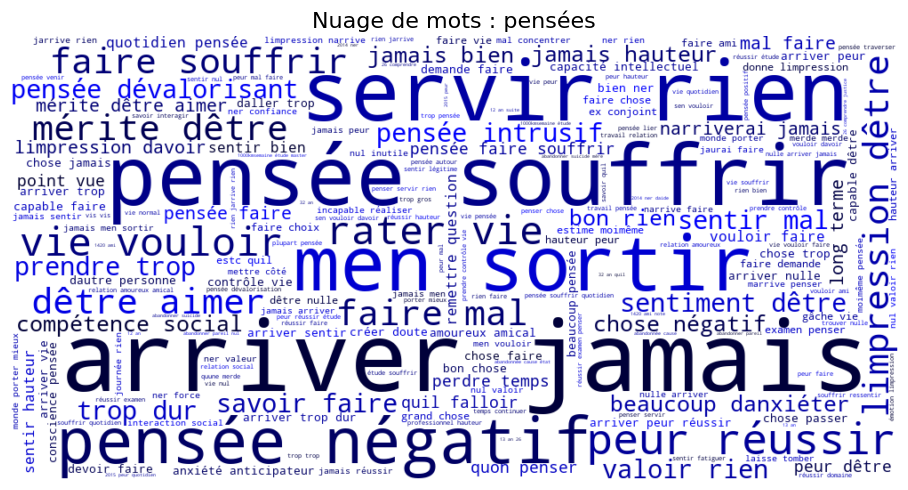

None


In [8]:
titre = "Nuage de mots : pensées"
colonne = 'Au quotidien, quelles sont les pensées (ex\xa0: «\xa0Je suis nul(le)\xa0») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0? '
couleur = couleurs[0 % len(couleurs)]  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur))

**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

In [9]:
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud, get_single_color_func
from sklearn.feature_extraction.text import CountVectorizer
import spacy

nlp = spacy.load("fr_core_news_sm")

### Wordcloud – Émotions

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question sur les émotions.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

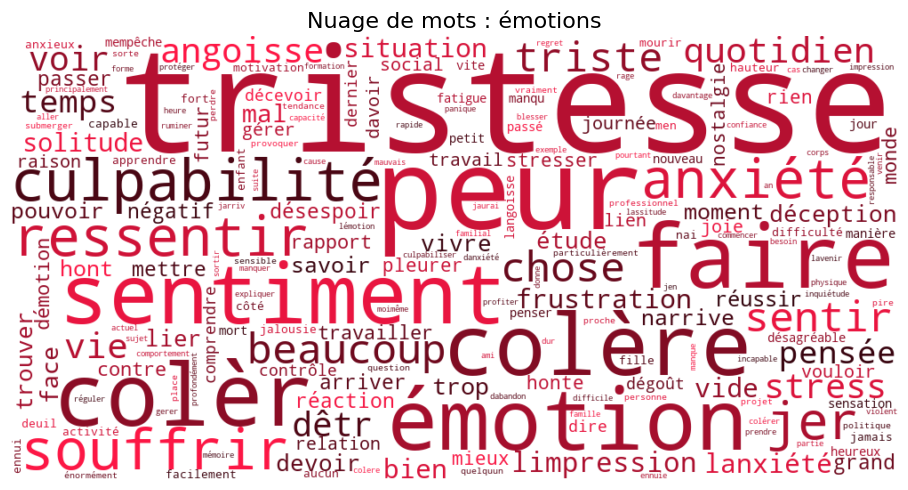

In [15]:
titre = "Nuage de mots : émotions"
colonne = "Au quotidien, quelles sont les émotions (ex\xa0: tristesse\xa0») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0? "
couleur = couleurs[1 % len(couleurs)]  # pour boucler sur les couleurs

generer_nuage(df, [colonne], titre=titre, ngram_range=(1, 1), couleur=couleur)


**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

### Wordcloud – Comportements

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les comportements*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

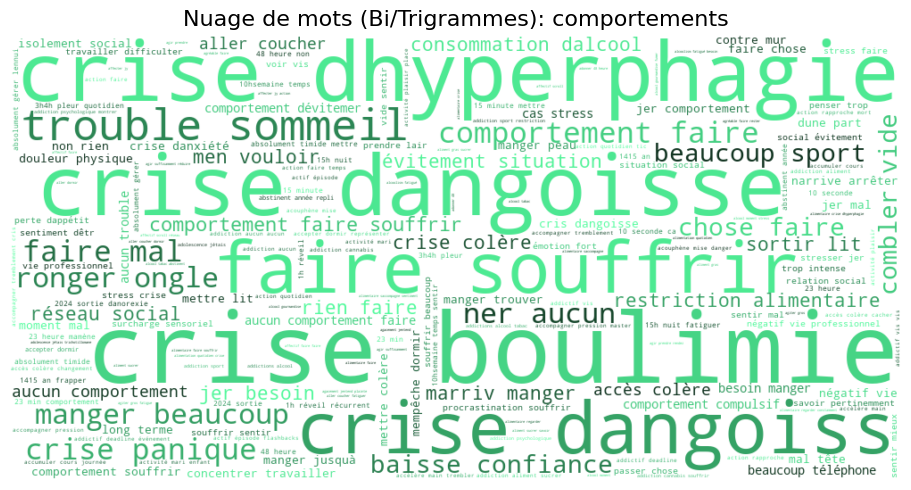

None


In [16]:
titre = "Nuage de mots (Bi/Trigrammes): comportements"
colonne = 'Au quotidien, quels sont les comportements (ex\xa0: des crises de boulimies) que vous avez qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0? '
couleur = couleurs[2 % len(couleurs)]  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur))

**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

### Wordcloud – Relations

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les relations*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

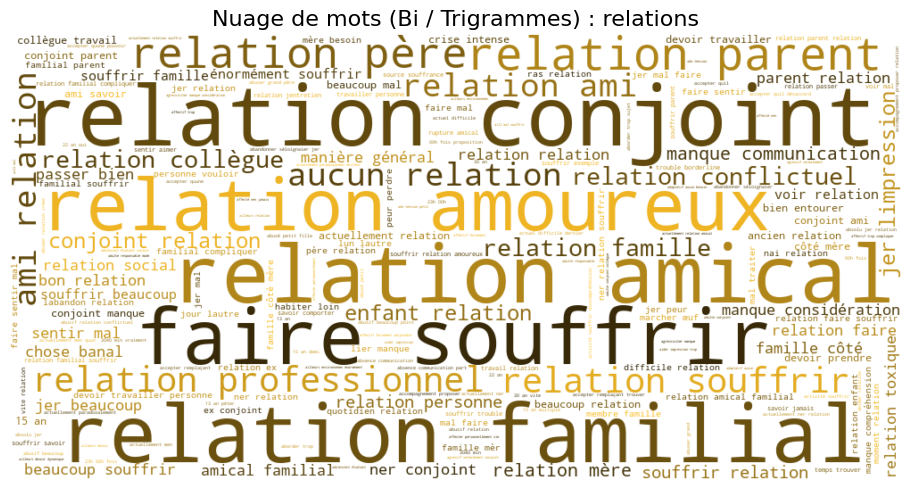

In [17]:
titre = "Nuage de mots (Bi / Trigrammes) : relations"
colonne = 'Au quotidien, quelles sont les relations (ex\xa0: relations avec votre conjoint(e)) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0?'

couleur = couleurs[3 % len(couleurs)]

generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur)


**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

### Wordcloud – Autres Souffrances

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les autres souffrances*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

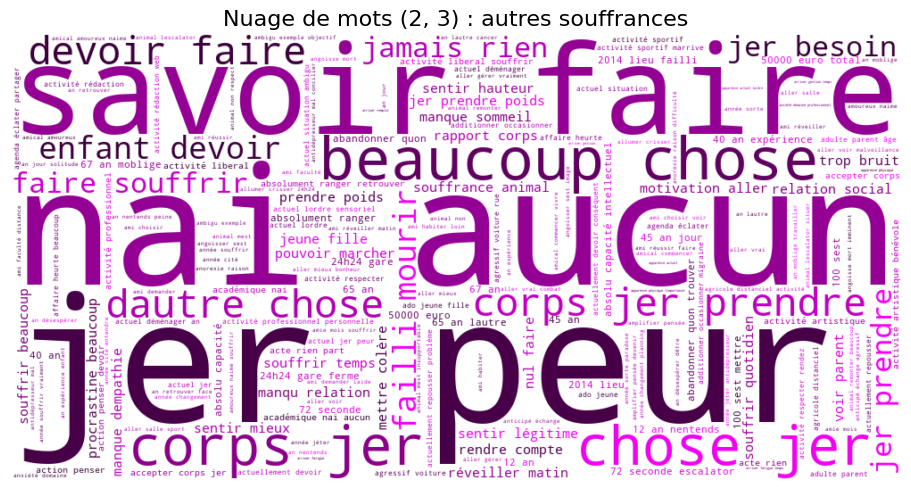

None


In [18]:
titre = "Nuage de mots (2, 3) : autres souffrances"
colonne = 'Au quotidien, quelles sont les autres choses qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0?'
couleur = couleurs[4 % len(couleurs)]  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur))

**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

### Wordcloud – Situations

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les situations*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

##### 1)

In [19]:
from wordcloud import WordCloud, get_single_color_func
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import spacy
import string

# === Chargement du modèle spaCy français ===
try:
    nlp = spacy.load("fr_core_news_md")
except:
    from spacy.cli import download
    download("fr_core_news_md")
    nlp = spacy.load("fr_core_news_md")

# === Fonction améliorée ===
def generer_nuage(df, colonnes, titre="Nuage de mots", ngram_range=(1, 2), largeur=1000, hauteur=500, couleur="black"):
    # 1. Fusion du texte brut
    texte = " ".join(
        df[col].dropna().astype(str).str.lower().str.cat(sep=' ') 
        for col in colonnes if col in df.columns
    )
    # 2. Nettoyage ponctuation
    texte = texte.translate(str.maketrans('', '', string.punctuation))

    # 3. Lemmatisation
    def lemmatize_text(text):
        doc = nlp(text)
        return " ".join([
            token.lemma_ for token in doc 
            if not token.is_stop and not token.is_punct and token.lemma_ != '-PRON-'
        ])
    
    texte_lemm = lemmatize_text(texte)

    # 4. Stopwords personnalisés (français)
    stopwords_perso = [
        "je", "me", "pas", "plus", "que", "dans", "de", "des", "les", "pour",
        "au", "aux", "avec", "sur", "ce", "ça", "c’est", "il", "elle", "elles", "ils",
        "suis", "tu", "nous", "vous", "on", "un", "une", "le", "la", "en", "et", "est",
        "être", "mon", "ma", "mes", "tes", "ton", "ta", "avoir", "fait", "ces", "parce", "ne", "qui", "jai", "cest", "ny", "dun", "nest",
    ]

    # 5. Extraction de n-grammes
    vectorizer = CountVectorizer(stop_words=stopwords_perso, ngram_range=ngram_range)
    X = vectorizer.fit_transform([texte_lemm])
    ngrams = vectorizer.get_feature_names_out()
    frequencies = X.toarray().flatten()
    freq_dict = dict(zip(ngrams, frequencies))

    # 6. Génération du nuage
    wordcloud = WordCloud(width=largeur, height=hauteur, background_color='white').generate_from_frequencies(freq_dict)

    # 7. Colorisation
    wordcloud.recolor(color_func=get_single_color_func(couleur))

    # 8. Affichage
    plt.figure(figsize=(largeur/100, hauteur/100))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(titre, fontsize=16)
    plt.tight_layout()
    plt.show()


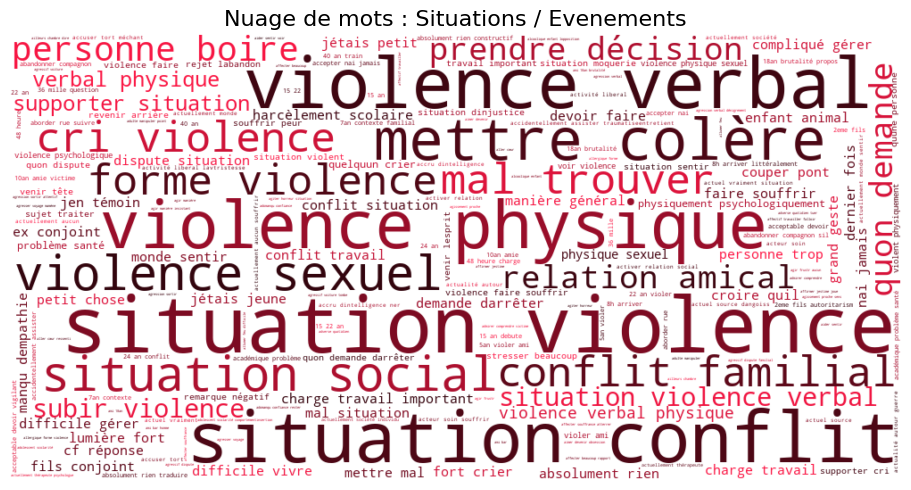

None


In [20]:
titre = "Nuage de mots : Situations / Evenements"
colonne = 'Quelles sont les situations et/ou les évènements (e.g. situations de violences) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer\xa0?'
couleur = couleurs[1 % len(couleurs)]  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur))

**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

### Wordcloud – Changement Quotidien

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur le changement quotidien*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

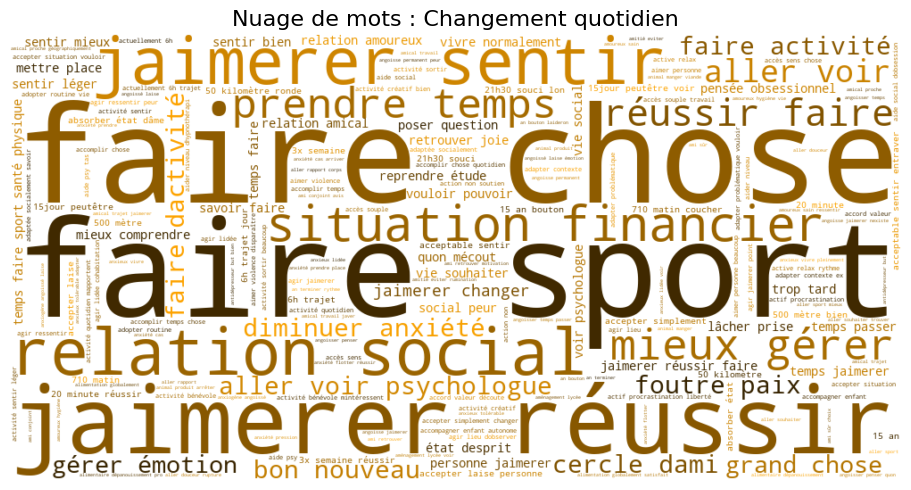

None


In [22]:
titre = "Nuage de mots : Changement quotidien"
colonne = 'Que voudriez-vous voir changer dans votre quotidien\xa0? '
couleur = 'orange'  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur))

**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

### Wordcloud – Troubles Passés

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les troubles passés*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

In [ ]:
titre = "Nuage de mots : Troubles passés"
colonne = "Merci d'indiquer ici le ou les troubles psychiatriques dont vous avez pu souffrir\xa0par le passé (si vous n'avez pas d'antécédent de trouble psychiatrique, passez à la question suivante)"
couleur = couleurs[6 % len(couleurs)]  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(1, 2), couleur=couleur))

#### 2)

In [ ]:
# Spécifiez le nom de la colonne à analyser (remplacez par le nom réel de la colonne dans votre fichier)
colonne_a_traiter = "Merci d'indiquer ici le ou les troubles psychiatriques dont vous avez pu souffrir\xa0par le passé (si vous n'avez pas d'antécédent de trouble psychiatrique, passez à la question suivante)"

# Vous pouvez tester avec différentes tailles d'n-grammes :
# Par exemple, pour des unigrams (ngram_size = 1) :
generer_wordcloud_white_list(df,
                             col=colonne_a_traiter,
                             whitelist=white_list,
                             ngram_size=1,
                             titre="WordCloud - Unigrams",
                             largeur=800,
                             hauteur=400)

# Pour des bigrammes (ngram_size = 2) :
generer_wordcloud_white_list(df,
                             col=colonne_a_traiter,
                             whitelist=white_list,
                             ngram_size=2,
                             titre="WordCloud - Bigrams",
                             largeur=800,
                             hauteur=400)


## Psychothérapies

In [29]:
liste_rep = [col for col in df.columns if col.endswith("_répondu") == True]
#df.drop(columns = liste_rep,axis = 1, inplace = True)

In [30]:
col_supp = [col for col in df.columns if "frein" in col]
listepsy = [col for col in df.columns if "psychothérapie" in col]
listepsy

['Si vous avez déjà suivi une psychothérapie, que vous a-t-elle apportée\xa0? ',
 'Si vous avez bénéficié de psychothérapie, qu’est ce qui a été travaillé avec votre thérapeute\xa0?']

### Wordcloud – Apports des Psychotéhrapies

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur les apports des psychothérapies*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

In [31]:
df.columns

Index(['Au quotidien, quelles sont les pensées (ex : « Je suis nul(le) ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quelles sont les émotions (ex : tristesse ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quels sont les comportements (ex : des crises de boulimies) que vous avez qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quelles sont les relations (ex : relations avec votre conjoint(e)) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?',
       'Quelles sont les situations et/ou les évènements (e.g. situations de violences) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?',
       'Au quotidien, quelles sont les autres choses qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?',
       'Que voudriez-vous voir c

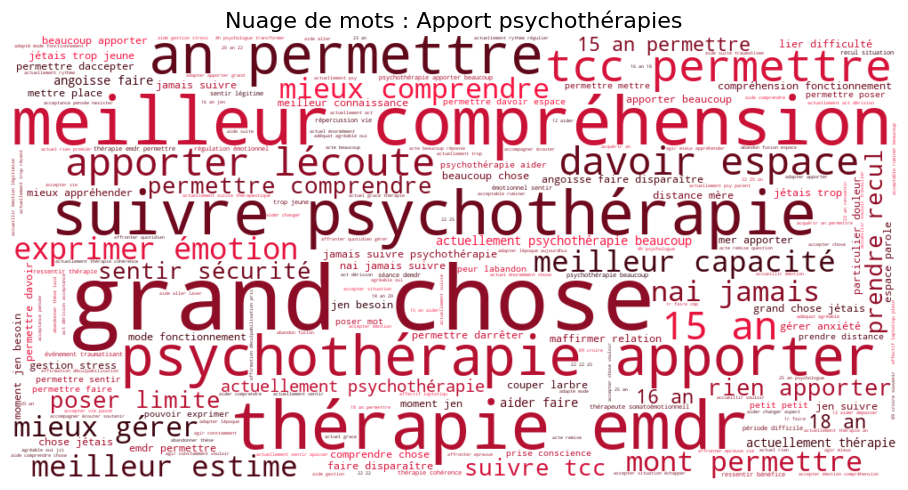

None


In [33]:
titre = "Nuage de mots : Apport psychothérapies"
colonne = listepsy[0]
couleur = couleurs[1 % len(couleurs)]  # pour boucler sur les couleurs

print(generer_nuage(df, [colonne], titre=titre, ngram_range=(2, 3), couleur=couleur))

**Remarque :**  
Cette visualisation brut reflète la fréquence brute des termes, mais ne permet pas
d’identifier des thèmes latents.  
L’analyse thématique est réalisée dans les notebooks *BERTopic E2* et *Analyse descriptive E2*.

In [34]:
colonnes_a_traiter = [repr(col) for col in df.columns if 'psychothérapie' in col]
colonnes_a_traiter = [col for col in df.columns if 'psychothérapie' in col]
colonnes_a_traiter

['Si vous avez déjà suivi une psychothérapie, que vous a-t-elle apportée\xa0? ',
 'Si vous avez bénéficié de psychothérapie, qu’est ce qui a été travaillé avec votre thérapeute\xa0?']

### Wordcloud – Travail avec thérapeute

Le nuage de mots ci-dessous illustre les termes les plus fréquemment cités dans
les réponses à la question *sur le travail avec le thérapeute*.

**Limites :**
- absence de prétraitement linguistique : stopwords et variations lexicales visibles ;
- importance à interpréter avec prudence (fréquence brute ≠ importance sémantique).

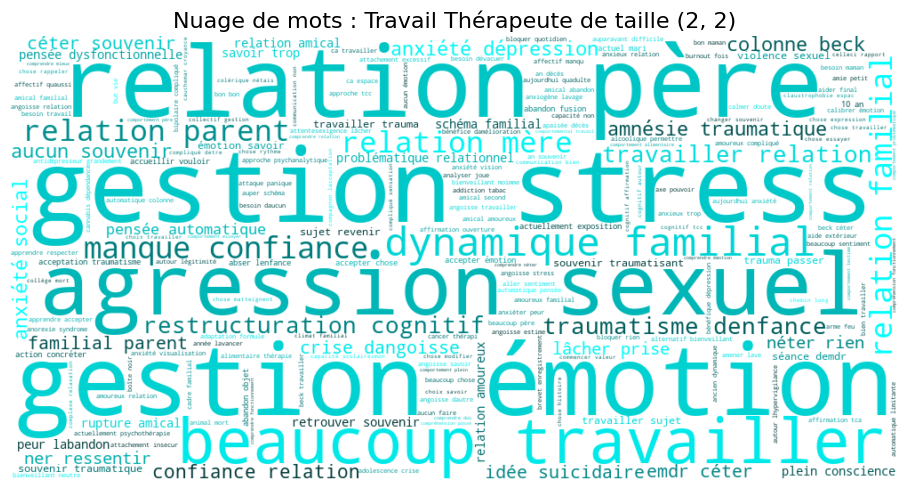

None


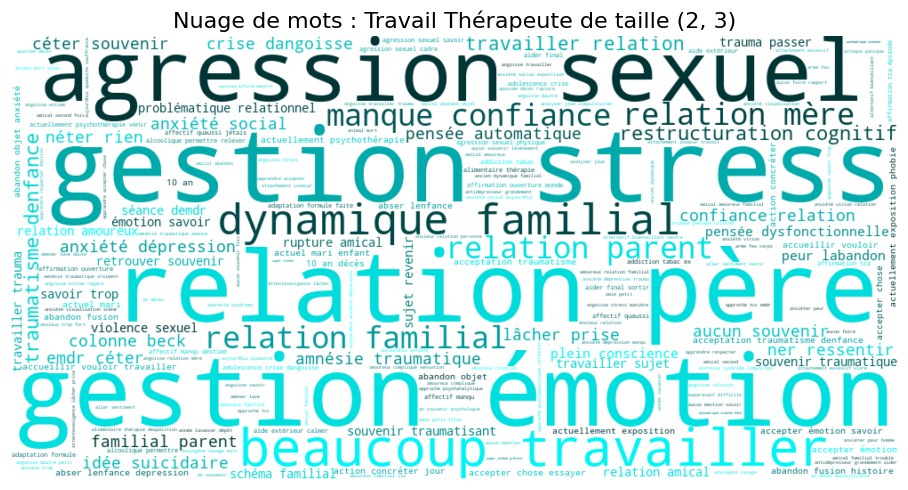

None


In [35]:
titre = "Nuage de mots : Travail Thérapeute"
colonne = listepsy[1]
couleur = couleurs[5 % len(couleurs)]  # pour boucler sur les couleurs

L = [(2, 3)]
for rang in L: 
    print(generer_nuage(df, [colonne], titre=titre + f" de taille {rang}", ngram_range=rang, couleur=couleur))

## Conclusion

Les wordclouds présentés dans ce notebook permettent une exploration visuelle rapide
des réponses ouvertes.  
Ils révèlent les mots les plus fréquents mais ne suffisent pas à dégager des
thématiques.  
L’interprétation clinique et la structuration en topics ont été réalisées dans les 
notebooks dédiés (BERTopic E2 / E3 / E4).


# WordCloud (Plusieurs colonnes)

In [ ]:
# Sélectionner les colonnes dont le type est 'object' ou 'string'
colonnes_texte = df.select_dtypes(include=['object', 'string']).columns.tolist()
colonnes_texte

In [ ]:
## Choix des colonnes de travail

Les réponses ouvertes sur le ressenti et l'expérience quotidienne
Ces colonnes contiennent des descriptions personnelles et détaillées, offrant une grande diversité de vocabulaire :

"Au quotidien, quelles sont les pensées (ex : « Je suis nul(le) ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?"

"Au quotidien, quelles sont les émotions (ex : tristesse) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?"

"Au quotidien, quels sont les comportements (ex : des crises de boulimies) que vous avez qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?"

"Au quotidien, quelles sont les relations (ex : relations avec votre conjoint(e)) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?"

"Quelles sont les situations et/ou les évènements (e.g. situations de violences) qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?"

"Au quotidien, quelles sont les autres choses qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ?"

Les réponses sur les perspectives d'évolution ou d'amélioration
Ces questions invitent à exprimer des idées et des attentes, apportant ainsi un vocabulaire intéressant pour voir ce qui motive les changements ou ce qui bloque l'amélioration :

"Que voudriez-vous voir changer dans votre quotidien ?"

"Qu’est-ce qui peut, selon vous, constituer un frein à l’amélioration de votre état ?"

Les retours sur l’expérience en psychothérapie
Ces colonnes offrent des retours d'expérience riches qui peuvent contenir des notions-clés sur ce qui a été bénéfique ou non lors d'un suivi thérapeutique :

"Si vous avez déjà suivi une psychothérapie, que vous a-t-elle apportée ?"

"Si vous avez bénéficié de psychothérapie, qu’est ce qui a été travaillé avec votre thérapeute ?"

"Commentaire libre" (s'il s'agit de retours ou d'observations personnelles)

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords


df1 = df.copy(deep = True)

# --- 1. Sélectionner uniquement les colonnes textuelles ---
colonnes_texte = df1.select_dtypes(include=['object', 'string']).columns.tolist()

# --- 2. Exclure les colonnes moins adaptées ---
# Ici, nous excluons celles qui semblent être des informations catégorielles ou non narratives.
colonnes_a_exclure = [
    'Langue de départ',
    'Genre',
    'Genre [Autre]',
    "Quel est votre niveau d'étude ?\xa0",
    'Activité Professionnelle - Autre',
    'Activité professionnelle',
    'Psychothérapies'
]

# On garde seulement les colonnes textuelles pertinentes pour le wordcloud
colonnes_texte_pertinentes = [col for col in colonnes_texte if col not in colonnes_a_exclure]

#print("Colonnes textuelles pertinentes pour le wordcloud :")
#print(colonnes_texte_pertinentes)

# --- 3. Nettoyage et prétraitement du texte ---

# Fonction de nettoyage du texte
def nettoyer_texte(texte):
    if isinstance(texte, str):
        texte = texte.lower()  # Passage en minuscules
        # Remplacer certains caractères indésirables par un espace
        texte = re.sub(r'[\n\r\t]', ' ', texte)
        # Supprimer la ponctuation
        texte = re.sub(r'[^\w\s]', '', texte)
        # Supprimer les espaces multiples
        texte = re.sub(r'\s+', ' ', texte)
        return texte.strip()
    return ""

# Appliquer le nettoyage sur chaque colonne pertinente
for col in colonnes_texte_pertinentes:
    df1[col] = df1[col].apply(nettoyer_texte)

# Optionnel : suppression des stopwords en français pour réduire le "bruit"
liste_stopwords = set(stopwords.words('french'))

def enlever_stopwords(texte):
    return " ".join([mot for mot in texte.split() if mot not in liste_stopwords])

for col in colonnes_texte_pertinentes:
    df1[col] = df1[col].apply(enlever_stopwords)

# Affichage d'un aperçu des colonnes nettoyées
#print("\nAperçu des colonnes textuelles nettoyées :")
#df[colonnes_texte_pertinentes].head()


#### 1) Selon les thématiques abordées

In [ ]:
Exp_quot = [col for col in df.columns if "Au quotidien" in col or "situations" in col]
Evo = [col for col in df.columns if "votre quotidien" in col or "frein" in col]
Psycho = [col for col in df.columns if "psychothérapie" in col ]


In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
import spacy

# Charger le modèle français de spaCy pour la lemmatisation
nlp = spacy.load('fr_core_news_sm')

# ------------------------------
# 1. Paramétrage des stopwords
# ------------------------------
nltk.download('stopwords', quiet=True)
default_stopwords = set(stopwords.words('french'))
stopwords_custom = {
    'ex', 'nan', 'exemple', 'car',
    # …
}
additional_stopwords = {
    "plus","être","avoir","faire","pouvoir","chose",
    "quel","quelle","quels","quelles","quelque",
    "cest","faut","jai","ça","cela","autre","autres",
    "grand","jer","jy","ny","quil","dun","nai",
    "donc","tout","rien","comme","si","là","où","jen","foutre"
}
stopwords_combined = default_stopwords | stopwords_custom | additional_stopwords

# ------------------------------
# 2. Choix de la taille des n-grammes
# ------------------------------
# Il suffit de changer ici :
min_n = 2   # n-grammes minimum (1 = unigrams)
max_n = 3   # n-grammes maximum (2 = bigrams, etc.)

ngram_range = (min_n, max_n)

# ------------------------------
# 3. Groupes de colonnes à traiter
# ------------------------------
# Remplacez Exp_quot, Evo, Psycho par vos listes de noms de colonnes
groupes = {
    "Ressenti et expérience quotidienne": Exp_quot,
    "Perspectives d'évolution ou d'amélioration": Evo,
    "Retours sur l’expérience en psychothérapie": Psycho
}

# ------------------------------
# Fonction de lemmatisation
# ------------------------------
def lemmatize_text(text: str) -> str:
    doc = nlp(text)
    return " ".join(tok.lemma_ for tok in doc)

# ------------------------------
# 4. Fonction de génération de wordclouds
# ------------------------------
def generate_group_wordclouds(
    df: pd.DataFrame,
    groupes: dict[str, list[str]],
    stop_words: set[str],
    ngram_range: tuple[int,int]
):
    for groupe, colonnes in groupes.items():
        # on concatène le contenu de chaque colonne présente
        texte = " ".join(
            " ".join(df[col].dropna().astype(str).tolist())
            for col in colonnes if col in df.columns
        )
        if not texte.strip():
            print(f"[SKIP] Aucune donnée pour « {groupe} »")
            continue

        # lemmatisation
        texte_lem = lemmatize_text(texte)

        # vectorisation et extraction des n-grammes
        vectorizer = CountVectorizer(
            stop_words=list(stop_words),
            ngram_range=ngram_range
        )
        X = vectorizer.fit_transform([texte_lem])
        freqs = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))

        # génération et affichage du wordcloud
        wc = WordCloud(
            width=800, height=400,
            background_color='white'
        ).generate_from_frequencies(freqs)

        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(groupe, fontsize=16)
        plt.show()

# ------------------------------
# 5. Lancer la génération
# ------------------------------
generate_group_wordclouds(
    df1,               # <— votre DataFrame
    groupes,
    stopwords_combined,
    ngram_range
)


#### 2) Toutes questions

In [ ]:

# Télécharger les stopwords français si nécessaire (décommentez la ligne suivante)
# nltk.download('stopwords')

# Charger le modèle français de spaCy pour la lemmatisation
nlp = spacy.load('fr_core_news_sm')

# ------------------------------
# 1. Paramétrage des stopwords
# ------------------------------
default_stopwords = set(stopwords.words('french'))
stopwords_custom = set([
    # Ajoutez ici vos propres stopwords personnalisés
    'ex', 'nan', 'exemple', "car", 
])

additional_stopwords = [
    "plus",
    "être",
    "avoir",
    "faire",
    "pouvoir",
    "chose",
    "quel",
    "quelle",
    "quels",
    "quelles",
    "quelque",
    "car",
    "cest",  # forme contractée de "c'est"
    "faut",
    "jai",  # forme contractée de "j'ai"
    "ça",
    "cela",
    "autre",
    "autres",
    "grand", "jer", "jy", "ny", "quil", "dun", "nai", "donc", "tout", "rien", "comme", "si", "là", "où", "jen", "foutre"
]

stopwords_combined = default_stopwords.union(stopwords_custom)
stopwords_combined = stopwords_combined.union(additional_stopwords)

# ------------------------------
# 2. Paramétrage des n-grams
# ------------------------------
# Définir la plage des n-grams désirée (par exemple (1,1) pour des unigrams, (1,2) pour unigrams + bigrams, etc.)
ngram_range = (2, 3)  # Modifiez ici si nécessaire

# ------------------------------
# 3. Définition des groupes de colonnes à traiter
# ------------------------------
groupes = {
    "Toutes questions ": Exp_quot + Evo + Psycho
}

# ------------------------------
# Fonction de lemmatisation
# ------------------------------
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc)

# ------------------------------
# 4. Génération des wordclouds par groupe
# ------------------------------
for groupe, colonnes in groupes.items():
    # Combiner les textes de chaque colonne (si la colonne est présente dans le DataFrame)
    texte_groupe = " ".join(" ".join(df1[col].dropna().tolist()) 
                            for col in colonnes if col in df1.columns)
    
    if len(texte_groupe.strip()) == 0:
        print(f"Aucune donnée pour le groupe : {groupe}")
        continue
    
    # Appliquer la lemmatisation au texte combiné
    texte_lemmatise = lemmatize_text(texte_groupe)
    
    # Extraire les n-grams et calculer leur fréquence à l'aide de CountVectorizer
    vectorizer = CountVectorizer(
    stop_words=list(stopwords_combined),  # Conversion de l'ensemble en liste
    ngram_range=ngram_range
)

    X = vectorizer.fit_transform([texte_lemmatise])
    
    # Créer un dictionnaire des fréquences
    frequencies = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))
    
    # Générer le wordcloud à partir des fréquences
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(frequencies)
    
    # Afficher le wordcloud pour le groupe
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(groupe)
    plt.show()
